Best parameters found:  {'C': 0.1, 'kernel': 'linear'}

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [29]:
df = pd.read_csv("Ready_Data.csv")
df.head()

,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumHeteroatoms,MolLogP,NumRings,...,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,Molecular Weight,label
0,1,4,58.64,0,1,2,4,5,4.8690,5,...,0,0,0,0,0,0,0,0,412.57,1
1,0,2,23.06,5,3,0,0,4,5.5489,3,...,0,0,0,0,0,0,0,0,391.36,0
2,1,3,30.49,5,1,1,1,3,2.9465,2,...,0,0,0,0,0,0,0,0,263.38,0
3,0,2,12.47,4,1,1,1,2,3.2801,2,...,0,0,0,0,0,0,0,0,247.38,0
4,1,3,32.70,7,1,1,1,3,4.1560,2,...,0,0,0,0,0,0,0,0,305.46,0


In [30]:
x = df.drop(["label"],axis=1)
y = df["label"]

In [31]:
with open('feature.pkl', 'rb') as f:
    expected_features = pickle.load(f)

In [32]:
x = pd.DataFrame(x, columns=expected_features)

In [33]:
x.head()

,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumHeteroatoms,MolLogP,NumRings,...,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,Molecular Weight
0,1,4,58.64,0,1,2,4,5,4.8690,5,...,0,0,0,0,0,0,0,0,0,412.57
1,0,2,23.06,5,3,0,0,4,5.5489,3,...,0,0,0,0,0,0,0,0,0,391.36
2,1,3,30.49,5,1,1,1,3,2.9465,2,...,0,0,0,0,0,0,0,0,0,263.38
3,0,2,12.47,4,1,1,1,2,3.2801,2,...,0,0,0,0,0,0,0,0,0,247.38
4,1,3,32.70,7,1,1,1,3,4.1560,2,...,0,0,0,0,0,0,0,0,0,305.46


In [34]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2,random_state=42)

In [35]:
model = SVC(C=0.1, kernel='linear', random_state=42)

In [36]:
model.fit(x_train,y_train)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [37]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)
print(f"Accuracy while training: {train_accuracy}")
print(f"Accuracy while testing: {test_accuracy}")

Accuracy while training: 0.9280338664158043
Accuracy while testing: 0.8759398496240601


In [38]:
cm = confusion_matrix(y_test,y_test_pred)
print(f"Confusion Metrix:\n{cm}")

Confusion Metrix:
[[117  88]
 [ 44 815]]


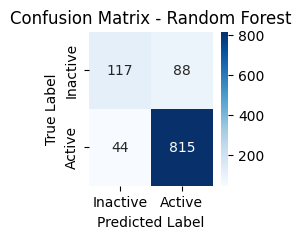

In [39]:
plt.figure(figsize=(2, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Inactive', 'Active'],
            yticklabels=['Inactive', 'Active'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [40]:
with open("support_vector_machine_Model.pkl","wb") as m:
    pickle.dump(model,m)